<a href="https://colab.research.google.com/github/Lawson-Dong/SINDy_code_reproduction/blob/main/ADAMSINDy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ADAM-SINDy: Harmonic Oscillator with Learnable Frequency

Noise level: 0.0

Ground Truth System:
  dx/dt = 1.0 * y
  dy/dt = -1.0 * x + 0.1 * y * cos(0.75 * x)

[1] Generating data...
    Data shape: (5000, 2)
    Time range: [0.0, 50.0], dt=0.010

[2] Training ADAM-SINDy...
Epoch     0 | Loss: 6.843378 | MSE: 6.843378 | L1: 0.0000 | ω_mix_cos: 0.5000
Epoch  1000 | Loss: 0.028401 | MSE: 0.014099 | L1: 0.0143 | ω_mix_cos: -0.0000
Epoch  2000 | Loss: 0.018871 | MSE: 0.014014 | L1: 0.0049 | ω_mix_cos: -0.0000
Epoch  3000 | Loss: 0.012511 | MSE: 0.010209 | L1: 0.0023 | ω_mix_cos: -0.0000
Epoch  4000 | Loss: 0.011399 | MSE: 0.010156 | L1: 0.0012 | ω_mix_cos: -0.0000
Epoch  5000 | Loss: 0.010876 | MSE: 0.010037 | L1: 0.0008 | ω_mix_cos: -0.0586
Epoch  6000 | Loss: 0.000997 | MSE: 0.000561 | L1: 0.0004 | ω_mix_cos: -0.4127
Epoch  7000 | Loss: 0.000249 | MSE: 0.000034 | L1: 0.0002 | ω_mix_cos: -0.7311

[3] Generating predictions...

DISCOVERED EQUATIONS

Ground Truth:
  dx/dt = 1.000 * y
  dy/

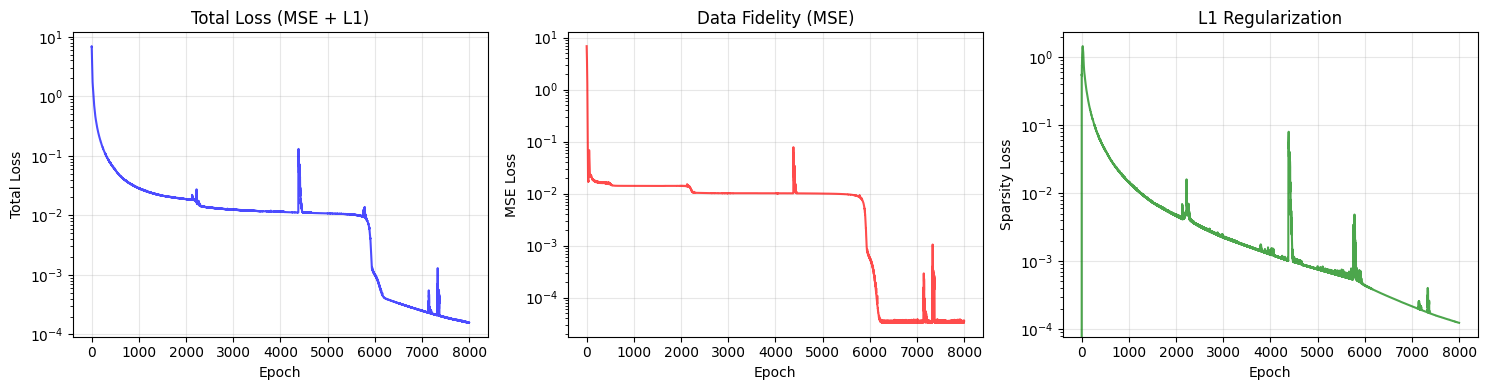

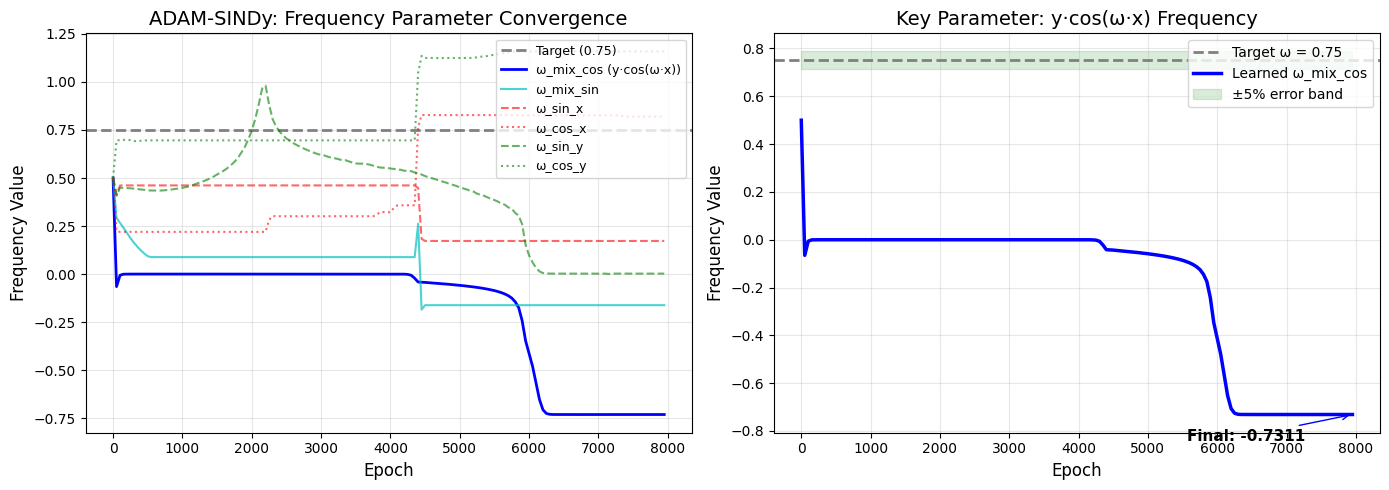

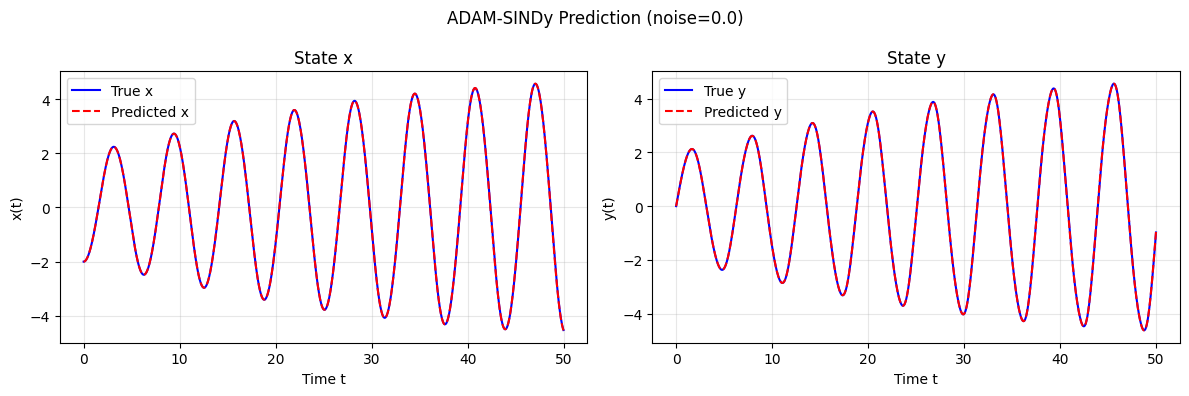


EXPERIMENT COMPLETE


In [1]:
"""
ADAM-SINDy Algorithm Demonstration
Based on: ADAM-SINDy (arXiv:2410.16528)
Focus: Visualizing the convergence of learnable frequency parameters during optimization
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ============================================================
# 1. Data Generation
# ============================================================
def harmonic_oscillator(t, state, a=1.0, b=1.0, c=0.1, d=0.75):
    """
    Ground truth system:
        dx/dt = a * y
        dy/dt = -b * x + c * y * cos(d * x)
    """
    x, y = state
    dx = a * y
    dy = -b * x + c * y * np.cos(d * x)
    return [dx, dy]

def generate_data(t_span=(0, 50), dt=0.01, noise_std=0.0, seed=42):
    """Generate trajectory data with optional Gaussian noise"""
    np.random.seed(seed)
    t_eval = np.arange(t_span[0], t_span[1], dt)
    sol = solve_ivp(harmonic_oscillator, t_span, [-2.0, 0.0], t_eval=t_eval, method='RK45')
    X = sol.y.T  # shape: (n_samples, 2)
    t = sol.t

    # Compute true derivatives
    dX = np.array([harmonic_oscillator(ti, xi) for ti, xi in zip(t, X)])

    # Add noise to state measurements
    X_noisy = X + np.random.normal(0, noise_std, X.shape)
    # Finite difference for derivatives
    dX_noisy = np.gradient(X_noisy, dt, axis=0)

    return X_noisy, dX_noisy, t, X, dX

# ============================================================
# 2. ADAM-SINDy Model (with cross-terms in library)
# ============================================================
class ADAMSINDy(nn.Module):
    """
    ADAM-SINDy model with learnable frequencies.
    Library includes:
        - Constant
        - Linear: x, y
        - Quadratic: x^2, y^2, x*y
        - Pure trig: sin(ω_s1*x), cos(ω_c1*x), sin(ω_s2*y), cos(ω_c2*y)
        - Mixed trig: y*cos(ω_m*x)  (key term for harmonic oscillator)
    """
    def __init__(self, n_states=2):
        super().__init__()
        self.n_states = n_states

        # Learnable frequencies
        # Pure sine/cosine frequencies for each state
        self.freq_sin = nn.Parameter(torch.ones(n_states) * 0.5)  # ω for sin
        self.freq_cos = nn.Parameter(torch.ones(n_states) * 0.5)  # ω for cos
        # Mixed term frequency: y * cos(ω * x)
        self.freq_mix_cos = nn.Parameter(torch.tensor(0.5))
        # Mixed term frequency: x * sin(ω * y) (optional, for symmetry)
        self.freq_mix_sin = nn.Parameter(torch.tensor(0.5))

        # Coefficients Xi (sparse)
        # Number of candidates will be determined in build_library
        self.n_candidates = None
        self.Xi = None

        # Candidate-wise sparsity weights (Gamma matrix, via log for positivity)
        self.log_gamma = None

        # Track frequencies during training for visualization
        self.freq_history = {
            'freq_sin_0': [], 'freq_sin_1': [],
            'freq_cos_0': [], 'freq_cos_1': [],
            'freq_mix_cos': [], 'freq_mix_sin': []
        }

    def initialize_coefficients(self, n_candidates):
        """Initialize Xi and Gamma after knowing library size"""
        self.n_candidates = n_candidates
        self.Xi = nn.Parameter(torch.zeros(n_candidates, self.n_states))
        self.log_gamma = nn.Parameter(torch.zeros(n_candidates, self.n_states))

    def build_library(self, X):
        """
        Construct candidate library with learnable frequencies.
        Returns: Theta matrix of shape (batch_size, n_candidates)
        """
        batch_size = X.shape[0]
        x = X[:, 0:1]  # shape: (batch, 1)
        y = X[:, 1:2]  # shape: (batch, 1)

        library = []

        # 1. Constant term
        library.append(torch.ones(batch_size, 1, device=X.device))

        # 2-3. Linear terms
        library.append(x)
        library.append(y)

        # 4-6. Quadratic terms
        library.append(x * x)
        library.append(y * y)
        library.append(x * y)

        # 7-10. Pure trigonometric terms
        library.append(torch.sin(self.freq_sin[0] * x))
        library.append(torch.cos(self.freq_cos[0] * x))
        library.append(torch.sin(self.freq_sin[1] * y))
        library.append(torch.cos(self.freq_cos[1] * y))

        # 11-14. Mixed terms (state * trig(other_state))
        # These are CRITICAL for discovering terms like y * cos(d * x)
        library.append(y * torch.sin(self.freq_mix_sin * x))  # y * sin(ω * x)
        library.append(y * torch.cos(self.freq_mix_cos * x))  # y * cos(ω * x)
        library.append(x * torch.sin(self.freq_mix_sin * y))  # x * sin(ω * y)
        library.append(x * torch.cos(self.freq_mix_cos * y))  # x * cos(ω * y)

        Theta = torch.cat(library, dim=1)
        return Theta

    def forward(self, X):
        Theta = self.build_library(X)
        dX_pred = Theta @ self.Xi
        return dX_pred, Theta

    def get_gamma(self):
        """Return positive Gamma matrix"""
        return torch.exp(self.log_gamma)

    def record_frequencies(self):
        """Record current frequency values for visualization"""
        self.freq_history['freq_sin_0'].append(self.freq_sin[0].item())
        self.freq_history['freq_sin_1'].append(self.freq_sin[1].item())
        self.freq_history['freq_cos_0'].append(self.freq_cos[0].item())
        self.freq_history['freq_cos_1'].append(self.freq_cos[1].item())
        self.freq_history['freq_mix_cos'].append(self.freq_mix_cos.item())
        self.freq_history['freq_mix_sin'].append(self.freq_mix_sin.item())

# ============================================================
# 3. Training Function
# ============================================================
def train_adam_sindy(X, dX, n_epochs=8000, lr=0.02, threshold=5e-3,
                     step_size=1500, gamma=0.8, verbose=True, record_every=50):
    """
    Train ADAM-SINDy model.

    Args:
        X, dX: numpy arrays of states and derivatives
        n_epochs: number of training epochs
        lr: initial learning rate
        threshold: sequential thresholding cutoff
        step_size: scheduler step size
        gamma: scheduler decay rate
        verbose: print progress
        record_every: record frequencies every N epochs
    """
    X_t = torch.tensor(X, dtype=torch.float32)
    dX_t = torch.tensor(dX, dtype=torch.float32)

    model = ADAMSINDy(n_states=X.shape[1])

    # First forward pass to determine library size
    with torch.no_grad():
        Theta_dummy = model.build_library(X_t)
        n_candidates = Theta_dummy.shape[1]

    model.initialize_coefficients(n_candidates)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    losses = []
    mse_losses = []
    sparsity_losses = []

    for epoch in range(n_epochs):
        optimizer.zero_grad()
        dX_pred, Theta = model(X_t)

        # Data fidelity loss (MSE)
        mse_loss = nn.MSELoss()(dX_pred, dX_t)
        # Sparsity loss with Gamma weighting (L1)
        gamma_mat = model.get_gamma()
        sparsity_loss = torch.sum(torch.abs(gamma_mat * model.Xi))
        # Total loss
        loss = mse_loss + sparsity_loss

        loss.backward()
        optimizer.step()
        scheduler.step()

        # Sequential thresholding
        with torch.no_grad():
            mask = torch.abs(model.Xi) < threshold
            model.Xi[mask] = 0.0

        # Record
        losses.append(loss.item())
        mse_losses.append(mse_loss.item())
        sparsity_losses.append(sparsity_loss.item())

        if epoch % record_every == 0:
            model.record_frequencies()

        if verbose and epoch % 1000 == 0:
            print(f"Epoch {epoch:5d} | Loss: {loss.item():.6f} | "
                  f"MSE: {mse_loss.item():.6f} | L1: {sparsity_loss.item():.4f} | "
                  f"ω_mix_cos: {model.freq_mix_cos.item():.4f}")

    return model, losses, mse_losses, sparsity_losses

# ============================================================
# 4. Extract and Display Discovered Equations
# ============================================================
def get_candidate_names():
    """Return human-readable names for each library term"""
    return [
        "1",                    # constant
        "x",                    # linear
        "y",
        "x^2",                  # quadratic
        "y^2",
        "x*y",
        "sin(ω_s1*x)",          # pure trig
        "cos(ω_c1*x)",
        "sin(ω_s2*y)",
        "cos(ω_c2*y)",
        "y*sin(ω_ms*x)",        # mixed
        "y*cos(ω_mc*x)",
        "x*sin(ω_ms*y)",
        "x*cos(ω_mc*y)"
    ]

def print_discovered_equations(model, threshold=1e-3):
    """Print the discovered governing equations"""
    names = get_candidate_names()
    Xi = model.Xi.detach().numpy()

    print("\n" + "="*60)
    print("DISCOVERED EQUATIONS")
    print("="*60)
    print("\nGround Truth:")
    print("  dx/dt = 1.000 * y")
    print("  dy/dt = -1.000 * x + 0.100 * y * cos(0.750 * x)")

    print("\nADAM-SINDy Discovered:")
    var_names = ['x', 'y']

    # Get learned frequencies
    with torch.no_grad():
        fs0, fs1 = model.freq_sin[0].item(), model.freq_sin[1].item()
        fc0, fc1 = model.freq_cos[0].item(), model.freq_cos[1].item()
        fm_cos = model.freq_mix_cos.item()
        fm_sin = model.freq_mix_sin.item()

    for i in range(2):
        terms = []
        for j, name in enumerate(names):
            coef = Xi[j, i]
            if abs(coef) > threshold:
                # Replace placeholder frequencies with actual learned values
                if "ω_s1" in name:
                    display_name = name.replace("ω_s1", f"{fs0:.4f}")
                elif "ω_s2" in name:
                    display_name = name.replace("ω_s2", f"{fs1:.4f}")
                elif "ω_c1" in name:
                    display_name = name.replace("ω_c1", f"{fc0:.4f}")
                elif "ω_c2" in name:
                    display_name = name.replace("ω_c2", f"{fc1:.4f}")
                elif "ω_mc" in name:
                    display_name = name.replace("ω_mc", f"{fm_cos:.4f}")
                elif "ω_ms" in name:
                    display_name = name.replace("ω_ms", f"{fm_sin:.4f}")
                else:
                    display_name = name
                terms.append(f"{coef:+.4f}*{display_name}")

        eq = "".join(terms) if terms else "0"
        print(f"  d{var_names[i]}/dt = {eq}")

    print("\n" + "="*60)
    print("LEARNED FREQUENCIES")
    print("="*60)
    print(f"  ω_sin_x  = {fs0:.6f}")
    print(f"  ω_sin_y  = {fs1:.6f}")
    print(f"  ω_cos_x  = {fc0:.6f}")
    print(f"  ω_cos_y  = {fc1:.6f}")
    print(f"  ω_mix_cos = {fm_cos:.6f}  (target: 0.75)")
    print(f"  ω_mix_sin = {fm_sin:.6f}")

# ============================================================
# 5. Visualization Functions
# ============================================================
def plot_training_curves(losses, mse_losses, sparsity_losses):
    """Plot loss curves during training"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(losses, 'b-', alpha=0.7)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Total Loss')
    axes[0].set_yscale('log')
    axes[0].set_title('Total Loss (MSE + L1)')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(mse_losses, 'r-', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE Loss')
    axes[1].set_yscale('log')
    axes[1].set_title('Data Fidelity (MSE)')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(sparsity_losses, 'g-', alpha=0.7)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Sparsity Loss')
    axes[2].set_yscale('log')
    axes[2].set_title('L1 Regularization')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig

def plot_frequency_convergence(model, ground_truth_freq=0.75):
    """
    Plot the convergence of learnable frequencies over epochs.
    This is the KEY visualization for ADAM-SINDy.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    history = model.freq_history
    n_records = len(history['freq_mix_cos'])
    epochs = np.arange(n_records) * 50  # record_every=50

    # Left plot: All frequencies
    axes[0].axhline(y=ground_truth_freq, color='gray', linestyle='--',
                    linewidth=2, label=f'Target (0.75)')
    axes[0].plot(epochs, history['freq_mix_cos'], 'b-', linewidth=2,
                 label='ω_mix_cos (y·cos(ω·x))')
    axes[0].plot(epochs, history['freq_mix_sin'], 'c-', linewidth=1.5,
                 alpha=0.7, label='ω_mix_sin')
    axes[0].plot(epochs, history['freq_sin_0'], 'r--', alpha=0.6, label='ω_sin_x')
    axes[0].plot(epochs, history['freq_cos_0'], 'r:', alpha=0.6, label='ω_cos_x')
    axes[0].plot(epochs, history['freq_sin_1'], 'g--', alpha=0.6, label='ω_sin_y')
    axes[0].plot(epochs, history['freq_cos_1'], 'g:', alpha=0.6, label='ω_cos_y')

    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Frequency Value', fontsize=12)
    axes[0].set_title('ADAM-SINDy: Frequency Parameter Convergence', fontsize=14)
    axes[0].legend(loc='upper right', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Right plot: Zoom on the key mixed frequency
    axes[1].axhline(y=ground_truth_freq, color='gray', linestyle='--',
                    linewidth=2, label=f'Target ω = {ground_truth_freq}')
    axes[1].plot(epochs, history['freq_mix_cos'], 'b-', linewidth=2.5,
                 label='Learned ω_mix_cos')

    # Add shaded region for ±5% error
    axes[1].fill_between(epochs, ground_truth_freq*0.95, ground_truth_freq*1.05,
                          alpha=0.15, color='green', label='±5% error band')

    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Frequency Value', fontsize=12)
    axes[1].set_title('Key Parameter: y·cos(ω·x) Frequency', fontsize=14)
    axes[1].legend(loc='upper right', fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # Annotate final value
    final_val = history['freq_mix_cos'][-1]
    axes[1].annotate(f'Final: {final_val:.4f}',
                     xy=(epochs[-1], final_val),
                     xytext=(epochs[-1]*0.7, final_val*1.15),
                     fontsize=11, fontweight='bold',
                     arrowprops=dict(arrowstyle='->', color='blue'))

    plt.tight_layout()
    return fig

def plot_trajectory_comparison(X_true, X_pred, t, title="Trajectory Comparison"):
    """Compare true vs predicted trajectories"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(t, X_true[:, 0], 'b-', linewidth=1.5, label='True x')
    axes[0].plot(t, X_pred[:, 0], 'r--', linewidth=1.5, label='Predicted x')
    axes[0].set_xlabel('Time t')
    axes[0].set_ylabel('x(t)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_title('State x')

    axes[1].plot(t, X_true[:, 1], 'b-', linewidth=1.5, label='True y')
    axes[1].plot(t, X_pred[:, 1], 'r--', linewidth=1.5, label='Predicted y')
    axes[1].set_xlabel('Time t')
    axes[1].set_ylabel('y(t)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_title('State y')

    plt.suptitle(title)
    plt.tight_layout()
    return fig

# ============================================================
# 6. Main Experiment
# ============================================================
def run_experiment(noise_std=0.0):
    """Run full ADAM-SINDy experiment with visualization"""
    print("="*60)
    print("ADAM-SINDy: Harmonic Oscillator with Learnable Frequency")
    print("="*60)
    print(f"\nNoise level: {noise_std}")
    print("\nGround Truth System:")
    print("  dx/dt = 1.0 * y")
    print("  dy/dt = -1.0 * x + 0.1 * y * cos(0.75 * x)")

    # Generate data
    print("\n[1] Generating data...")
    X_noisy, dX_noisy, t, X_true, dX_true = generate_data(noise_std=noise_std)
    print(f"    Data shape: {X_noisy.shape}")
    print(f"    Time range: [{t[0]:.1f}, {t[-1]:.1f}], dt={t[1]-t[0]:.3f}")

    # Train ADAM-SINDy
    print("\n[2] Training ADAM-SINDy...")
    model, losses, mse_losses, sparsity_losses = train_adam_sindy(
        X_noisy, dX_noisy,
        n_epochs=8000,
        lr=0.02,
        threshold=1e-3,
        step_size=1500,
        gamma=0.85,
        verbose=True
    )

    # Predict trajectory
    print("\n[3] Generating predictions...")
    X_t = torch.tensor(X_noisy, dtype=torch.float32)
    with torch.no_grad():
        dX_pred, _ = model(X_t)
        dX_pred = dX_pred.numpy()

    # Integrate predicted derivatives to get trajectory
    from scipy.integrate import odeint
    def predicted_system(state, t):
        x, y = state
        X_in = torch.tensor([[x, y]], dtype=torch.float32)
        with torch.no_grad():
            dX, _ = model(X_in)
        return dX.numpy().flatten()

    X_pred = odeint(predicted_system, X_true[0], t)

    # Print discovered equations
    print_discovered_equations(model)

    # Visualization
    print("\n[4] Generating visualizations...")

    # Figure 1: Loss curves
    fig1 = plot_training_curves(losses, mse_losses, sparsity_losses)
    plt.show()

    # Figure 2: Frequency convergence (KEY FIGURE)
    fig2 = plot_frequency_convergence(model, ground_truth_freq=0.75)
    plt.show()

    # Figure 3: Trajectory comparison
    fig3 = plot_trajectory_comparison(X_true, X_pred, t,
                                       title=f"ADAM-SINDy Prediction (noise={noise_std})")
    plt.show()

    return model, losses

# ============================================================
# 7. Run Everything
# ============================================================
if __name__ == "__main__":
    # Run with clean data (noise=0)
    model, losses = run_experiment(noise_std=0.0)

    print("\n" + "="*60)
    print("EXPERIMENT COMPLETE")
    print("="*60)